<a href="https://colab.research.google.com/github/ylepen/NPL--M2-DG/blob/main/BERTopic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Text Clustering**

Three steps:



1.   Convert the input documents to embeddings with an **embedding model**
2.   Reduce the dimensionality of embeddings with a **dimensionality reduction model**
3.  Finds groups of semantically similar documents with a **cluster model**



In [ ]:
from datasets import load_dataset
dataset = load_dataset("maartengr/arxiv_nlp")["train"]
abstracts = dataset["Abstracts"]
titles = dataset["Titles"]
#

Step 1: embedding the documents

In [ ]:
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer("thenlper/gte-small")
embeddings = embedding_model.encode(abstracts,show_progress_bar=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: thenlper/gte-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1405 [00:00<?, ?it/s]

In [ ]:
embeddings.shape

(44949, 384)

Step 2: Reduction of dimensionality

**UMAP (Uniform Manifold Approximation and Projection)** is a dimensionality reduction technique, meaning it transforms high-dimensional data (e.g. vectors of 768 dimensions) into a low-dimensional representation (2D or 3D) for visualization or analysis.

The core idea is to preserve both local and global structure of the data. UMAP first builds a neighborhood graph in the original space — each point is connected to its nearest neighbors. It then projects this graph into a reduced space while trying to maintain those proximity relationships as faithfully as possible.

In [ ]:
from umap import UMAP
umap_model=UMAP(
    n_components=5,
    min_dist=0.0,
    metric="cosine",
)

reduced_embeddings = umap_model.fit_transform(embeddings)
reduced_embeddings.shape

(44949, 5)

Step 3: Uncovering clusters

In [ ]:
from hdbscan import HDBSCAN
hdbscan_model = HDBSCAN(
    min_cluster_size=50,
    metric="euclidean",
    cluster_selection_method="eom",
).fit(reduced_embeddings)

In [ ]:
clusters=hdbscan_model.labels_

In [ ]:
len(set(clusters))

155

In [ ]:
import numpy as np

cluster = 0
for index in np.where(clusters == cluster)[0][:3]:
    print(abstracts[int(index)][:300] + '....\n')

  This works aims to design a statistical machine translation from English text
to American Sign Language (ASL). The system is based on Moses tool with some
modifications and the results are synthesized through a 3D avatar for
interpretation. First, we translate the input text to gloss, a written fo....

  Researches on signed languages still strongly dissociate lin- guistic issues
related on phonological and phonetic aspects, and gesture studies for
recognition and synthesis purposes. This paper focuses on the imbrication of
motion and meaning for the analysis, synthesis and evaluation of sign lang....

  Modern computational linguistic software cannot produce important aspects of
sign language translation. Using some researches we deduce that the majority of
automatic sign language translation systems ignore many aspects when they
generate animation; therefore the interpretation lost the truth inf....



Reducing dimensionality to 2 to make a graphical representation

In [ ]:
import pandas as pd
reduced_embeddings=UMAP(
    n_components=2,
    min_dist=0.0,
    metric="cosine",
).fit_transform(embeddings)

In [ ]:
df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])
df["title"] = titles
df["cluster"] = [str(c) for c in clusters]

cluster_df=df.loc[df.cluster != "-1",:]
outliers_df=df.loc[df.cluster == "-1",:]

(np.float64(-7.717686676979065),
 np.float64(11.674910092353821),
 np.float64(-5.686474180221557),
 np.float64(10.310601568222046))

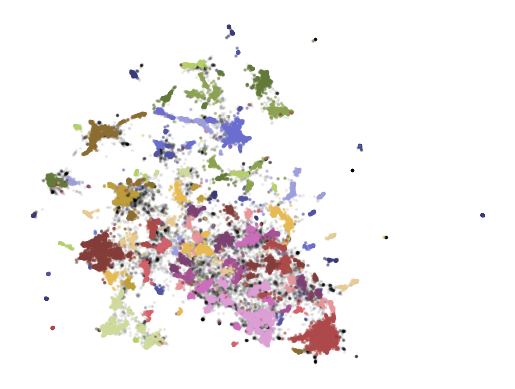

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(outliers_df.x,outliers_df.y,alpha=0.05,s=2,c='black')
plt.scatter(
    cluster_df.x,cluster_df.y,c=cluster_df.cluster.astype(int),alpha=0.5,s=2,cmap='tab20b'
)
plt.axis('off')

**BERTopic**

Used for topic modeling

Principle: finding clusters of semantically similar texts to obtain topics as previously

plus: an interpretation of topics based on a topic-level tf-idf

Representing topics through the computation of topic-level tf-idf to

tf = compute the frequency of a word within a topic = $f_{t,c}/|c|$ where $|c|$ : number of words of topic c

$IDF_{t}$ = compute the frequency of a word across topics = $log(1+A/\bar{f}_{t})$

A : average number of words per class (topic) accross all topics

$\bar{f}_{t}$ = mean frequency of word t across all topics

$c-TF-IDF_{t} = TF_{t} \times IDF_{t}$

put more weight on words which are more relevant to each topic

put less weights on words which appeared in all documents (all topics)

In [ ]:
pip install bertopic

In [ ]:
from bertopic import BERTopic

We run BERTopic with the preceeding:

- embedding model
- reduction of dimensionality model


In [ ]:
topic_model = BERTopic(
    embedding_model= embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True,
).fit(abstracts,embeddings)

2026-02-16 13:07:04,095 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-16 13:08:06,109 - BERTopic - Dimensionality - Completed ✓
2026-02-16 13:08:06,116 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-16 13:08:10,135 - BERTopic - Cluster - Completed ✓
2026-02-16 13:08:10,157 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-16 13:08:17,812 - BERTopic - Representation - Completed ✓


To vizualize the topic

In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,14681,-1_the_of_and_to,"[the, of, and, to, in, we, language, for, that...",[ Large-scale generative language models such...
1,0,2209,0_speech_asr_recognition_end,"[speech, asr, recognition, end, acoustic, spea...",[ Spoken language understanding (SLU) tasks i...
2,1,2194,1_question_answer_qa_questions,"[question, answer, qa, questions, answering, a...",[ Multilingual question answering tasks typic...
3,2,1122,2_medical_clinical_biomedical_patient,"[medical, clinical, biomedical, patient, notes...","[ Large language models (LLMs), such as ChatG..."
4,3,918,3_translation_nmt_machine_neural,"[translation, nmt, machine, neural, bleu, engl...",[ Improving neural machine translation (NMT) ...
...,...,...,...,...,...
146,145,52,145_materials_chemical_science_chemistry,"[materials, chemical, science, chemistry, mate...",[ Information extraction and textual comprehe...
147,146,52,146_gans_gan_adversarial_generation,"[gans, gan, adversarial, generation, generativ...",[ Text generation is of particular interest i...
148,147,52,147_mixed_code_sentiment_mixing,"[mixed, code, sentiment, mixing, english, anal...",[ In today's interconnected and multilingual ...
149,148,52,148_prompt_prompts_optimization_prompting,"[prompt, prompts, optimization, prompting, llm...",[ Prompt optimization aims to find the best p...


Displaying topic 0

In [ ]:
topic_model.get_topic(0)

[('speech', np.float64(0.029150834269918262)),
 ('asr', np.float64(0.019267871153763463)),
 ('recognition', np.float64(0.013866967890465513)),
 ('end', np.float64(0.010138581489771816)),
 ('acoustic', np.float64(0.009728196021458782)),
 ('speaker', np.float64(0.007075946329903221)),
 ('audio', np.float64(0.006884451424917945)),
 ('the', np.float64(0.006541835489005426)),
 ('error', np.float64(0.006477655719165549)),
 ('wer', np.float64(0.0064732091043024345))]

To which topic is associated a given expression

In [ ]:
topic_model.find_topics('topic_modelling')

([24, -1, 42, 2, 128],
 [np.float64(0.921520168854013),
  np.float64(0.8891438012983653),
  np.float64(0.8832253388450189),
  np.float64(0.8800486496329055),
  np.float64(0.8783943361046038)])

In [ ]:
topic_model.get_topic(24)

[('topic', np.float64(0.07013965456324833)),
 ('topics', np.float64(0.036486261877093945)),
 ('lda', np.float64(0.01676860027666732)),
 ('document', np.float64(0.01359779550759115)),
 ('latent', np.float64(0.013278394956545059)),
 ('documents', np.float64(0.013251516513510099)),
 ('modeling', np.float64(0.012563878721586078)),
 ('dirichlet', np.float64(0.009801645918748114)),
 ('word', np.float64(0.00898862850223936)),
 ('allocation', np.float64(0.007895159310765856))]

In [ ]:
topic_model.topics_[titles.index("BERTopic: Neural topic modeling with a class-based TF-IDF procedure")]

24

Visualize topics and documents

with reduced embeddings: we reduce embeddings to dimension 2

In [ ]:
fig = topic_model.visualize_documents(
    list(titles),
    reduced_embeddings=reduced_embeddings,
    width=1200,
    hide_annotations=True
)

In [ ]:
fig.update_layout(font=dict(size=16))

In [ ]:
topic_model.visualize_barchart()

In [ ]:
topic_model.visualize_hierarchy()

In [ ]:
topic_model.visualize_heatmap()

We save the model

In [ ]:
from copy import deepcopy
original_topics=deepcopy(topic_model.topic_representations_)

Reranking the initial set of results

We take previous results and apply a reranking model to obtain a better representation of the results.

We define a function to display the difference between words associated to each topic before and after reranking

In [ ]:
def topic_differences(model,original_topics,nr_topics=5):
  df=pd.DataFrame(columns=['Topic','Original','Updated'])
  for topic in range(nr_topics):
    og_words ="|".join(list(zip(*original_topics[topic]))[0][:5])
    new_words ="|".join(list(zip(*model.get_topic(topic)))[0][:5])
    df.loc[len(df)]=[topic,og_words,new_words]
  return df

We used KeyBERTInspired

based on KeyBERT : extract keyword from document by comparing word and documents embeddings through cosine similarity

Extract the most significant document per topic by computing the similarity of the ct-TF-IDF of the document and those of the topic to which it belongs

The most significant document is compared to candidate keywords to rerank the the keywords

In [ ]:
representation_model=KeyBERTInspired()
topic_model.update_topics(abstracts,representation_model=representation_model)

In [ ]:
topic_differences(topic_model,original_topics)

,Topic,Original,Updated
0,0,speech|asr|recognition|end|acoustic,transcription|phonetic|speech|spoken|voice
1,1,question|answer|qa|questions|answering,answering|questions|question|comprehension|answer
2,2,medical|clinical|biomedical|patient|notes,nlp|clinical|ehr|ehrs|language
3,3,translation|nmt|machine|neural|bleu,translation|translating|translate|translations...
4,4,summarization|summaries|summary|abstractive|do...,summarization|summarizers|summaries|summary|ab...
